# **MODELO XGBOOST PARA LA CLASIFICACIÓN DE TOPICS**

Modelo para la clasificación multiclase de la columna `Topic`, entrenado con el conjunto de datos de noticias reales `MLSUM (Multilingual Summarization Corpus) - Subconjunto en Español`: https://huggingface.co/datasets/reciTAL/mlsum/tree/refs%2Fconvert%2Fparquet/es. El cual cuenta con más de 260.000 noticias reales extraídas de medios en castellano (solo en su partición de entrenamiento).

## **INSTALACIÓN DE DEPENDENCIAS**

In [ ]:
#!pip install pandas xgboost scikit-learn spacy tqdm matplotlib seaborn
#!python -m spacy download es_core_news_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import joblib
import os
import time

import spacy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb

# Configuramos tqdm con pandas
from tqdm.auto import tqdm
tqdm.pandas()

## **PREPROCESAMIENTO Y PREPARACIÓN DEL CONJUNTO DE DATOS**

In [2]:
print("Cargando dataset...")
df = pd.read_csv('../Data/Topic/Dataset_Topic_Classifier.csv')
print(f"Registros iniciales: {len(df)}")
df.head()

Cargando dataset...
Registros iniciales: 290645


,ID,Content,Title,Topic
0,TOP_1,"De momento, no podemos responder a la pregunta...",¿Quién ganó en las campanadas?,elpais actualidad
1,TOP_2,Los vuelos han venido registrando este viernes...,Las aerolíneas denuncian retrasos en Barajas p...,elpais actualidad
2,TOP_3,El Gobierno turco ha anunciado que emprenderá ...,Turquía reclama a Italia la devolución de los ...,elpais actualidad
3,TOP_4,La policía de Finlandia ha informado este vier...,El autor del tiroteo de Finlandia escogió a su...,internacional actualidad
4,TOP_5,"""Hemos descubierto un agujero vertical en la L...",Descubierto un agujero vertical en la Luna,sociedad actualidad


Distribución de Tópicos Agrupados:
Topic_Grouped
España / Local               75198
Política                     49426
Cultura y Entretenimiento    45620
Sociedad y Estilo de Vida    29520
Internacional                28516
Economía                     24130
Deportes                     20239
Otros                        13096
Ciencia y Tecnología          4900
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_16424\1190061437.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Topic_Grouped', order=df['Topic_Grouped'].value_counts().index, palette='viridis')


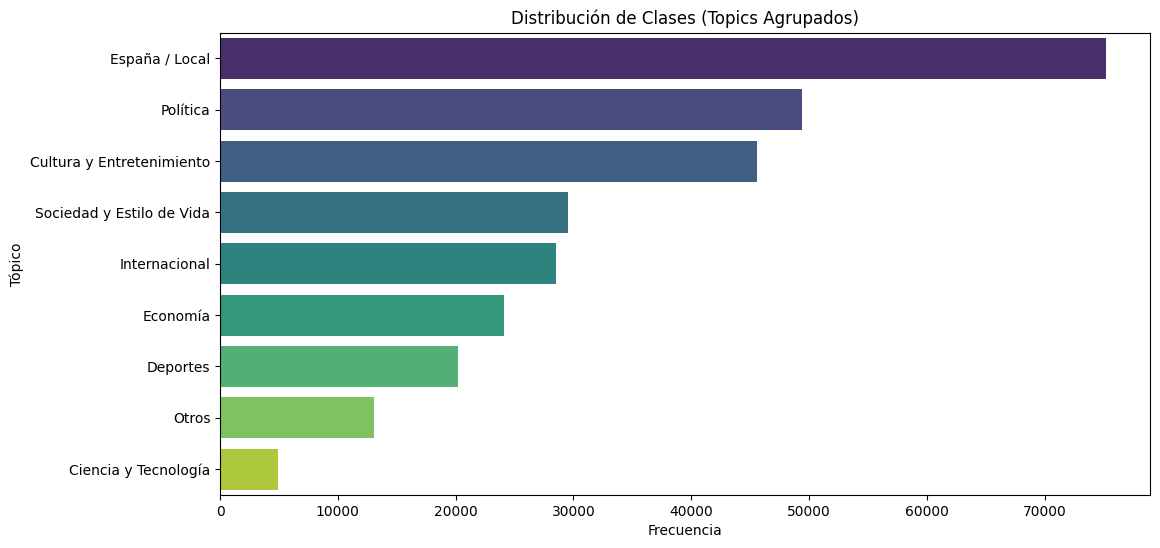

In [3]:
def map_topic(topic):
    topic = str(topic).lower()
    if any(k in topic for k in ['deporte', 'futbol', 'baloncesto', 'olimpico', 'champions', 'eurocopa', 'adrenalina']):
        return 'Deportes'
    elif any(k in topic for k in ['politica', 'congreso', 'opinion', 'genova', 'eldebate']):
        return 'Política'
    elif any(k in topic for k in ['economia', 'negocio', 'empleo', 'vivienda', 'finanzas', 'ahorro', 'mercado']):
        return 'Economía'
    elif any(k in topic for k in ['tecnologia', 'ciencia', 'motor', 'ciberpais', 'techie', 'digital']):
        return 'Ciencia y Tecnología'
    elif any(k in topic for k in ['cultura', 'cine', 'television', 'babelia', 'tentaciones', 'eps', 'icon', 'vinetas', 'arte', 'album']):
        return 'Cultura y Entretenimiento'
    elif any(k in topic for k in ['internacional', 'america', 'mexico', 'estados_unidos', 'colombia', 'argentina', 'mundo']):
        return 'Internacional'
    elif any(k in topic for k in ['sociedad', 'gente', 'estilo', 'viajero', 'salud', 'educacion', 'mamas', 'buenavida', 'planeta_futuro']):
        return 'Sociedad y Estilo de Vida'
    elif any(k in topic for k in ['ccaa', 'catalunya', 'madrid', 'valencia', 'paisvasco', 'galicia', 'andalucia', 'espana', 'cvalenciana', 'cat ']) or 'elpais actualidad' in topic:
        return 'España / Local'
    else:
        return 'Otros'

# Aplicamos el mapeo de categorías
df['Topic_Grouped'] = df['Topic'].apply(map_topic)

# Eliminamos nulos y vacíos en campos críticos
df = df.dropna(subset=['Title', 'Content', 'Topic_Grouped'])
df = df.drop_duplicates(subset=['Title', 'Content'])
df = df[(df['Title'].str.strip() != '') & (df['Content'].str.strip() != '')]

print("Distribución de Tópicos Agrupados:")
print(df['Topic_Grouped'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Topic_Grouped', order=df['Topic_Grouped'].value_counts().index, palette='viridis')
plt.title('Distribución de Clases (Topics Agrupados)')
plt.xlabel('Frecuencia')
plt.ylabel('Tópico')
plt.show()

In [4]:
# Cargar modelo de SpaCy optimizado
try:
    nlp = spacy.load('es_core_news_sm')
except OSError:
    print("Descargando el modelo es_core_news_sm...")
    import spacy.cli
    spacy.cli.download("es_core_news_sm")
    nlp = spacy.load('es_core_news_sm')

# Aumentar el límite de longitud por documento en SpaCy
nlp.max_length = 2000000 

def regex_clean(text):
    """Limpieza básica rápida con RegEx"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'<.*?>', '', text) # HTML tags
    text = re.sub(r'[^a-záéíóúñü\s]', ' ', text) # Solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip() # Espacios múltiples
    return text

def spacy_clean_batch(texts, batch_size=256):
    """Procesamiento avanzado con SpaCy para Lematización y Stopwords"""
    cleaned_docs = []
    # Deshabilitamos componentes innecesarios del pipeline para mayor velocidad
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size, disable=["parser", "ner"]), total=len(texts), desc="Procesando NLP"):
        # Conservamos solo letras, que no sean stopwords y lematizamos
        tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
        cleaned_docs.append(" ".join(tokens))
    return cleaned_docs

print("1. Uniendo Título y Contenido y aplicando limpieza Regex básica...")
# Creamos una nueva columna uniendo ambos textos
df['Texto_Completo'] = df['Title'] + " " + df['Content']

# Aplicamos la limpieza sobre la nueva columna unida
df['Regex_Content'] = df['Texto_Completo'].progress_apply(regex_clean)

print("2. Aplicando procesamiento SpaCy (Lematización y Stopwords)...")
# Convertir a lista para pasarlo a nlp.pipe de manera más eficiente
texts_to_process = df['Regex_Content'].tolist()
df['Cleaned_Content'] = spacy_clean_batch(texts_to_process)

# Borramos las columnas intermedias para liberar RAM
df = df.drop(columns=['Regex_Content', 'Texto_Completo'])

print("¡Preprocesamiento completado!")

display(df[['Title', 'Content', 'Cleaned_Content', 'Topic_Grouped']].head())

1. Uniendo Título y Contenido y aplicando limpieza Regex básica...


  0%|          | 0/290645 [00:00<?, ?it/s]

2. Aplicando procesamiento SpaCy (Lematización y Stopwords)...


Procesando NLP:   0%|          | 0/290645 [00:00<?, ?it/s]

¡Preprocesamiento completado!


,Title,Content,Cleaned_Content,Topic_Grouped
0,¿Quién ganó en las campanadas?,"De momento, no podemos responder a la pregunta...",ganar campanada momento responder pregunta fri...,España / Local
1,Las aerolíneas denuncian retrasos en Barajas p...,Los vuelos han venido registrando este viernes...,aerolínea denunciar retraso baraja provocado c...,España / Local
2,Turquía reclama a Italia la devolución de los ...,El Gobierno turco ha anunciado que emprenderá ...,turquía reclamar italia devolución resto santo...,España / Local
3,El autor del tiroteo de Finlandia escogió a su...,La policía de Finlandia ha informado este vier...,autor tiroteo finlandia escoger víctima policí...,Internacional
4,Descubierto un agujero vertical en la Luna,"""Hemos descubierto un agujero vertical en la L...",descubrir agujero vertical luna descubrir aguj...,Sociedad y Estilo de Vida


## **SPLIT Y REPRESENTACIÓN CON TF-IDF**

In [5]:
print("1. Transformando etiquetas a formato numérico...")
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Topic_Grouped'])

print("Mapeo de clases:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"{idx}: {cls}")

print("\n2. Dividiendo el dataset (80% Entrenamiento, 20% Prueba)...")
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Content'], 
    df['Target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['Target']
)
print(f"Set de Entrenamiento: {len(X_train)} muestras")
print(f"Set de Prueba: {len(X_test)} muestras")

print("\n3. Vectorizando el texto con TF-IDF...")
vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))

# Ajustamos y transformamos el conjunto de entrenamiento
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transformamos el conjunto de prueba (SIN ajustar de nuevo para evitar Data Leakage)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones de la matriz TF-IDF (Entrenamiento): {X_train_tfidf.shape}")

1. Transformando etiquetas a formato numérico...
Mapeo de clases:
0: Ciencia y Tecnología
1: Cultura y Entretenimiento
2: Deportes
3: Economía
4: España / Local
5: Internacional
6: Otros
7: Política
8: Sociedad y Estilo de Vida

2. Dividiendo el dataset (80% Entrenamiento, 20% Prueba)...
Set de Entrenamiento: 232516 muestras
Set de Prueba: 58129 muestras

3. Vectorizando el texto con TF-IDF...
Dimensiones de la matriz TF-IDF (Entrenamiento): (232516, 30000)


### **PREPARAR MATRICES PARA GPU**

In [6]:
# 0. Adaptando datos para la GPU
print("Pasando matrices a 32 bits y ordenando índices...")
X_train_tfidf = X_train_tfidf.astype(np.float32)
X_train_tfidf.sort_indices()

X_test_tfidf = X_test_tfidf.astype(np.float32)
X_test_tfidf.sort_indices()

print("Datos listos para el entrenamiento!")

Pasando matrices a 32 bits y ordenando índices...
Datos listos para el entrenamiento!


## **ENTRENAMIENTO DEL MODELO XGBOOST**

Iniciando el entrenamiento del modelo XGBoost con GPU
[0]	validation_0-mlogloss:2.05348	validation_1-mlogloss:2.05365
[5]	validation_0-mlogloss:1.71253	validation_1-mlogloss:1.71427
[10]	validation_0-mlogloss:1.49911	validation_1-mlogloss:1.50168
[15]	validation_0-mlogloss:1.34314	validation_1-mlogloss:1.34720
[20]	validation_0-mlogloss:1.22410	validation_1-mlogloss:1.22978
[25]	validation_0-mlogloss:1.13028	validation_1-mlogloss:1.13738
[30]	validation_0-mlogloss:1.05371	validation_1-mlogloss:1.06208
[35]	validation_0-mlogloss:0.99135	validation_1-mlogloss:1.00112
[40]	validation_0-mlogloss:0.93908	validation_1-mlogloss:0.95012
[45]	validation_0-mlogloss:0.89422	validation_1-mlogloss:0.90647
[50]	validation_0-mlogloss:0.85467	validation_1-mlogloss:0.86848
[55]	validation_0-mlogloss:0.82111	validation_1-mlogloss:0.83613
[60]	validation_0-mlogloss:0.79175	validation_1-mlogloss:0.80801
[65]	validation_0-mlogloss:0.76601	validation_1-mlogloss:0.78379
[70]	validation_0-mlogloss:0.74276	val

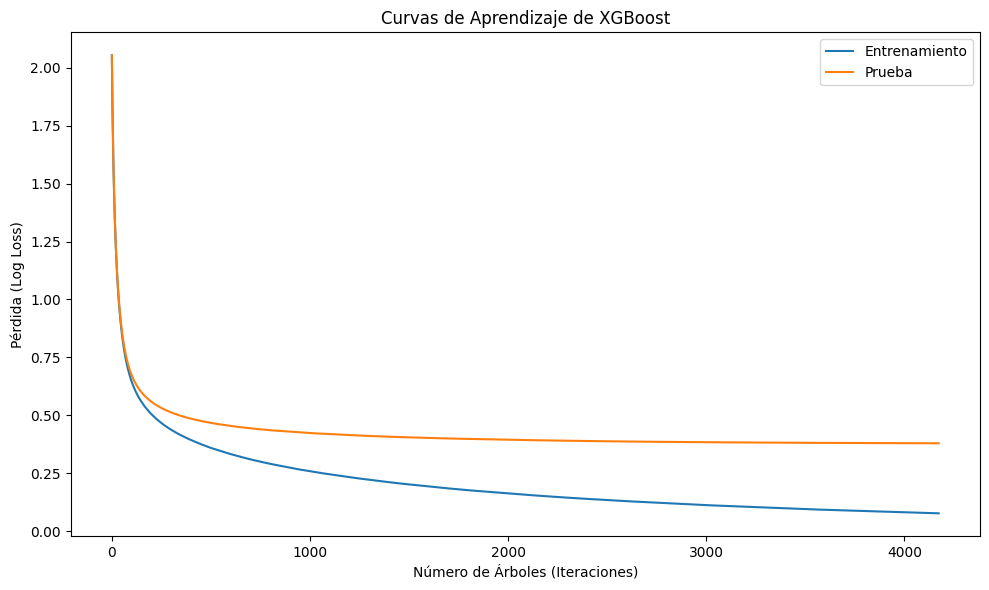

In [8]:
print("Iniciando el entrenamiento del modelo XGBoost con GPU")
start_time = time.time()

# 1. Configuración con GPU activada
xgb_model = xgb.XGBClassifier(
    n_estimators=30000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    random_state=42,
    early_stopping_rounds=20,
    n_jobs=-1,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss'
)

# 2. Convertimos las etiquetas a arrays puros para evitar desalineación de índices
y_train_array = y_train.values
y_test_array = y_test.values

evals = [(X_train_tfidf, y_train_array), (X_test_tfidf, y_test_array)]

# 3. Entrenamiento
xgb_model.fit(
    X_train_tfidf, y_train_array,
    eval_set=evals,
    verbose=5  
)

end_time = time.time()
print(f"¡Entrenamiento completado en {end_time - start_time:.2f} segundos!")

# 4. Graficar curvas de aprendizaje
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Entrenamiento')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Prueba')
plt.legend()
plt.ylabel('Pérdida (Log Loss)')
plt.xlabel('Número de Árboles (Iteraciones)')
plt.title('Curvas de Aprendizaje de XGBoost')
plt.tight_layout()
plt.show()

## **GUARDADO DEL MODELO Y ARTEFACTOS**

In [9]:
print("Guardando modelo y artefactos para producción...")
os.makedirs('artefactos', exist_ok=True)

# 1. Guardar el modelo XGBoost
xgb_model.save_model('artefactos/xgboost_topic_classifier.pkl')

# 2. Guardar el Vectorizador TF-IDF
joblib.dump(vectorizer, 'artefactos/tfidf_vectorizer.pkl')

# 3. Guardar el Label Encoder
joblib.dump(label_encoder, 'artefactos/label_encoder.pkl')

print("¡Todo guardado correctamente en la carpeta 'artefactos'!")

Guardando modelo y artefactos para producción...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [08:39:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


¡Todo guardado correctamente en la carpeta 'artefactos'!


## **EVALUACIÓN DEL MODELO**

Realizando predicciones en el conjunto de prueba...

--- REPORTE DE CLASIFICACIÓN ---
                           precision    recall  f1-score   support

     Ciencia y Tecnología       0.78      0.66      0.71       980
Cultura y Entretenimiento       0.85      0.89      0.87      9124
                 Deportes       0.99      0.99      0.99      4048
                 Economía       0.85      0.87      0.86      4826
           España / Local       0.88      0.91      0.90     15040
            Internacional       0.85      0.89      0.87      5703
                    Otros       0.88      0.74      0.81      2619
                 Política       0.89      0.87      0.88      9885
Sociedad y Estilo de Vida       0.82      0.76      0.79      5904

                 accuracy                           0.87     58129
                macro avg       0.87      0.84      0.85     58129
             weighted avg       0.87      0.87      0.87     58129

Generando Matriz de Confusión profesiona

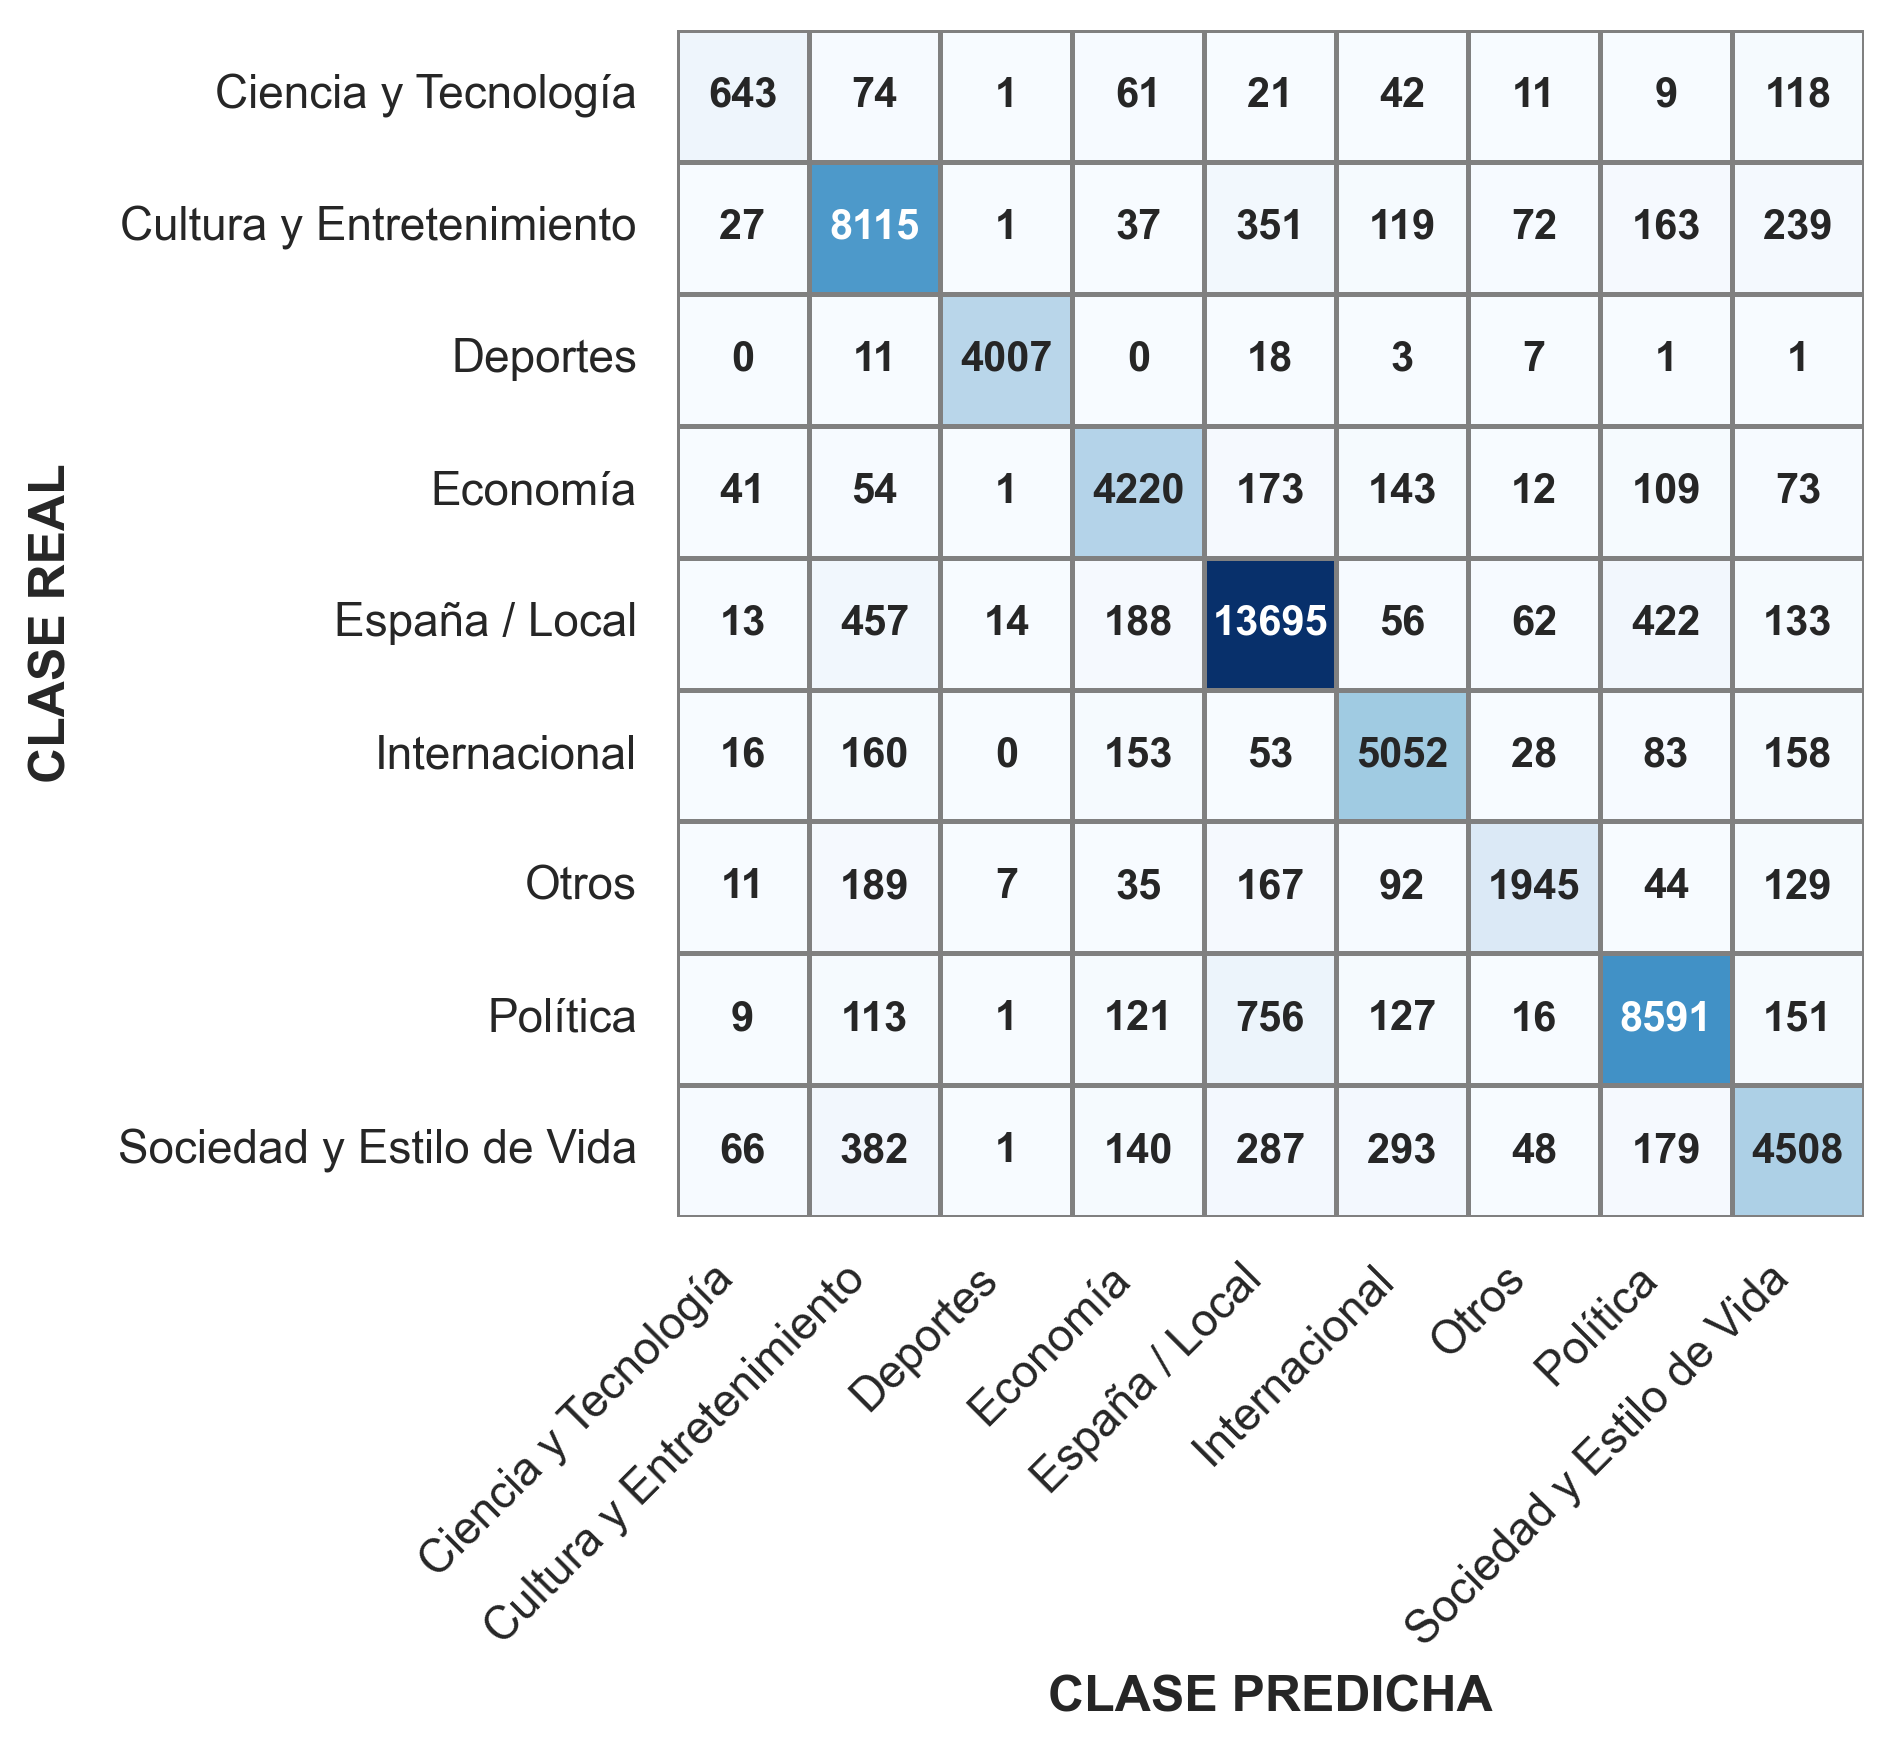

In [32]:
print("Realizando predicciones en el conjunto de prueba...")
y_pred = xgb_model.predict(X_test_tfidf)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("Generando Matriz de Confusión profesional...")
cm = confusion_matrix(y_test, y_pred)

# GRAFICAMOS LA MATRIZ DE CONFUSIÓN
# ==============================================================================
TAMANO_LABELS = 12      # "CLASE PREDICHA" y "CLASE REAL"
TAMANO_CLASES = 12      # Nombres de las categorías
TAMANO_NUMEROS = 10     # Números dentro de la matriz

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['axes.labelsize'] = TAMANO_LABELS
mpl.rcParams['xtick.labelsize'] = TAMANO_CLASES
mpl.rcParams['ytick.labelsize'] = TAMANO_CLASES
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
sns.heatmap(
    cm,
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    annot_kws={
        "size": TAMANO_NUMEROS, 
        "fontweight": "bold", 
        "family": "sans-serif" 
    }, 
    linewidths=0.8,     # Líneas más gruesas
    linecolor='gray',   # Líneas de la tabla negras
    cbar=False,          
    square=True          
)
ax.set_xlabel('CLASE PREDICHA', labelpad=5, fontweight='bold')
ax.set_ylabel('CLASE REAL', labelpad=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figuras/matriz_confusion_topic_clasiffier.png', dpi=300, bbox_inches='tight')
plt.show()

### **CELDA DE INFERENCIA PARA PRODUCCIÓN**

In [13]:
print("Cargando modelo y artefactos desde disco...")
modelo_prod = xgb.XGBClassifier()
modelo_prod.load_model('artefactos/xgboost_topic_classifier.pkl')
vectorizador_prod = joblib.load('artefactos/tfidf_vectorizer.pkl')
encoder_prod = joblib.load('artefactos/label_encoder.pkl')

# Función de Inferencia:
def clasificar_nueva_noticia(titulo, contenido):
    """Pipeline completo para clasificar un texto en crudo"""
    
    # Unimos título y contenido
    texto_combinado = titulo + " " + contenido
    
    # Paso 1: Limpieza básica 
    texto_regex = regex_clean(texto_combinado)
    
    # Paso 2: Procesamiento NLP con SpaCy
    texto_nlp = spacy_clean_batch([texto_regex], batch_size=1)[0]
    
    # Paso 3: Vectorización TF-IDF
    texto_tfidf = vectorizador_prod.transform([texto_nlp])
    
    # Paso 4: Adaptar formato para la GPU 
    texto_tfidf = texto_tfidf.astype(np.float32)
    texto_tfidf.sort_indices()
    
    # Paso 5: Predicción
    clase_numerica = modelo_prod.predict(texto_tfidf)
    
    # Paso 6: Decodificar el número a texto
    categoria_final = encoder_prod.inverse_transform(clase_numerica)[0]
    
    return categoria_final

# Ejecución de Inferencia
# ==============================================================
titulo_prueba = "Bajada histórica de tipos del BCE"
contenido_prueba = "El Banco Central Europeo anuncia una bajada histórica de los tipos de interés. Esta medida busca estimular la concesión de hipotecas y frenar la inflación en el mercado de la vivienda."

print("\nProcesando noticia de prueba...")
categoria_predicha = clasificar_nueva_noticia(titulo_prueba, contenido_prueba)

print("-" * 50)
print("RESULTADO DEL MODELO:")
print("-" * 50)
print(f"TÍTULO: {titulo_prueba}")
print(f"CONTENIDO: {contenido_prueba}")
print(f"PREDICCIÓN: {categoria_predicha.upper()}")

Cargando modelo y artefactos desde disco...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py:1125: UserWarning: [08:44:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1511: Unknown file format: `pkl`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)



Procesando noticia de prueba...


Procesando NLP:   0%|          | 0/1 [00:00<?, ?it/s]

--------------------------------------------------
RESULTADO DEL MODELO:
--------------------------------------------------
TÍTULO: Bajada histórica de tipos del BCE
CONTENIDO: El Banco Central Europeo anuncia una bajada histórica de los tipos de interés. Esta medida busca estimular la concesión de hipotecas y frenar la inflación en el mercado de la vivienda.
PREDICCIÓN: ECONOMÍA
